In [1]:
from pycirclize import Circos
from pycirclize.utils import ColorCycler
import numpy as np
import pandas as pd
np.random.seed(0)

In [15]:
chr_bed_file = '../data/hg38_chr.bed'
cytoband_file = '../data/hg38_cytoband.tsv'
chr_links_total = pd.read_csv('../data/leopard_cohort/clustered_sv_input.bedpe', sep='\t')
sample = '18138-010BL'
#gene = 'TP53'
gene = False
other_sample = False
check_clustering = True
#other_sample = '18138-072BL'
#clustered_sample = '18138-098BL'
clustered_sample = False

# add "chr" to the chromosome column
chr_links_total['chrom1'] = 'chr' + chr_links_total['chrom1'].astype(str)
chr_links_total['chrom2'] = 'chr' + chr_links_total['chrom2'].astype(str)
# change 23 to X and 24 to Y
chr_links_total['chrom1'] = chr_links_total['chrom1'].replace('chr23', 'chrX')
chr_links_total['chrom1'] = chr_links_total['chrom1'].replace('chr24', 'chrY')
chr_links_total['chrom2'] = chr_links_total['chrom2'].replace('chr23', 'chrX')
chr_links_total['chrom2'] = chr_links_total['chrom2'].replace('chr24', 'chrY')

chr_links = chr_links_total.copy()
chr_links = chr_links[chr_links['sample'] == sample]

if check_clustering: 

    clustered_sv_region = pd.read_csv('../outputs/leopard_cohort/merged_clustered_sv_events.csv')

    if clustered_sample:
        clustered_sv_region = clustered_sv_region[clustered_sv_region['sample'] == clustered_sample]
        clustered_sv_region['chr'] = 'chr' + clustered_sv_region['chr'].astype(str)
    else:
        clustered_sv_region = clustered_sv_region[clustered_sv_region['sample'] == sample]
        clustered_sv_region['chr'] = 'chr' + clustered_sv_region['chr'].astype(str)

    if other_sample:
        chr_links_other = chr_links_total.copy()
        chr_links_other = chr_links_other[chr_links_other['sample'] == other_sample]

    def overlaps_any_cluster(chrom, start, end, regions):
        sub = regions[regions["chr"] == chrom]
        if sub.empty:
            return False
        return (
            (sub["start"] <= end) & (sub["end"] >= start)
        ).any()

    chr_links = chr_links.copy()
    chr_links["is_clustered"] = chr_links.apply(
        lambda r: overlaps_any_cluster(r["chrom1"], r["start1"], r["end1"], clustered_sv_region)
        or overlaps_any_cluster(r["chrom2"], r["start2"], r["end2"], clustered_sv_region),
        axis=1,
    ).astype(int)
else:
    chr_links["is_clustered"] = 0

chr_bed = pd.read_csv(chr_bed_file, sep='\t')
#chr_bed = chr_bed[chr_bed['#chrom'].isin(['chr1', 'chr2', 'chr5', 'chr6', 'chr8', 'chr12', 'chr17', 'chr21', 'chr22', 'chrX'])]
chr_bed.to_csv('../data/chr_bed_filtered.bed', sep='\t', index=False)

chr_links = chr_links[chr_links['chrom1'].isin(chr_bed['#chrom'])]
chr_links = chr_links[chr_links['chrom2'].isin(chr_bed['#chrom'])]

if other_sample:
    buffer = 20  # bp of slop on each breakpoint

    other_groups = {
        cp: g[['start1', 'start2']].to_numpy()
        for cp, g in chr_links_other.groupby(['chrom1', 'chrom2'])
    }

    seen = np.zeros(len(chr_links), dtype=int)
    for i, row in enumerate(chr_links.itertuples(index=False)):
        cand = other_groups.get((row.chrom1, row.chrom2))
        if cand is None:
            continue
        q = np.array([row.start1, row.start2])
        if np.any(np.all(np.abs(cand - q) <= buffer, axis=1)):
            seen[i] = 1

    chr_links['seen_in_other'] = seen
    print(chr_links['seen_in_other'].sum())
else:
    chr_links['seen_in_other'] = 0

chr_links.head()

print("Total SVs: ", len(chr_links))
print("SVs clustered: ", chr_links['is_clustered'].sum())
#print("SVs clustered and seen in other sample: ", len(chr_links[(chr_links['is_clustered'] == 1) & (chr_links['seen_in_other'] == 1)]))


Total SVs:  119
SVs clustered:  82


0


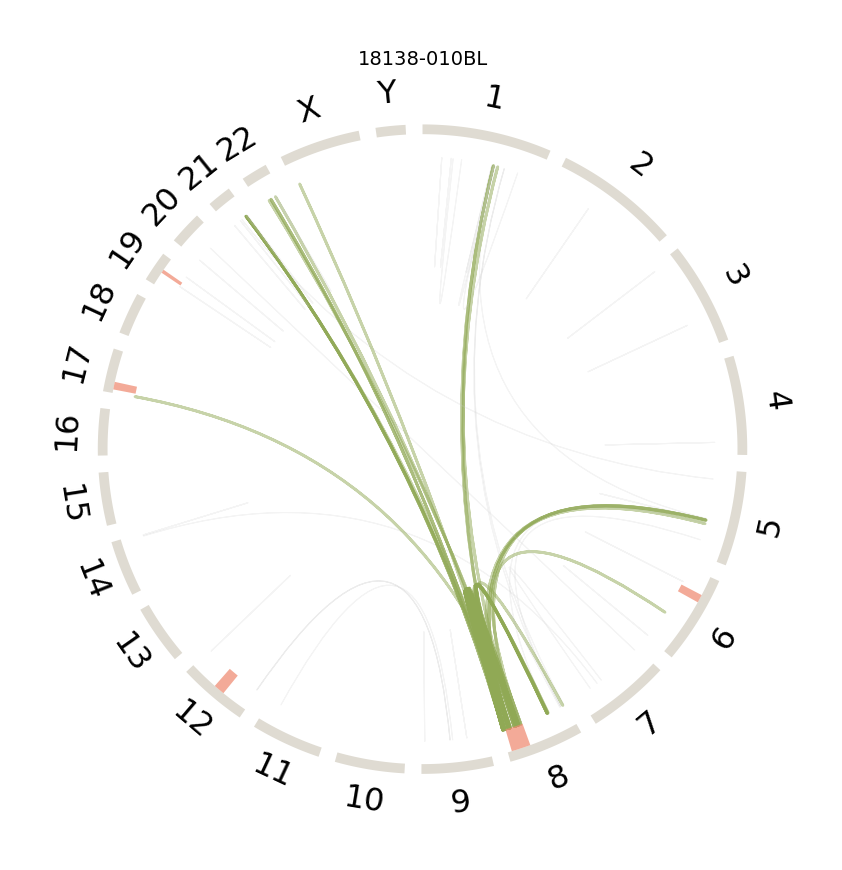

In [16]:
from matplotlib.patches import Patch

hotspots = {
    'CCND3': {'chrom': 'chr6', 'start': 39000000, 'end': 55000000, 'color': '#ee876cdb'},
    'MYC': {'chrom': 'chr8', 'start': 99000000, 'end': 137000000, 'color': '#ee876cdb'},
    'CDK4-MDM2': {'chrom': 'chr12', 'start': 53000000, 'end': 75000000, 'color': '#ee876cdb'},
    'CCNE1': {'chrom': 'chr19', 'start': 27000000, 'end': 34000000, 'color': '#ee876cdb'},
    'TP53': {'chrom': 'chr17', 'start': 7000000, 'end': 22000000, 'color': '#ee876cdb'}
}
genes = {
    'TP53': {'chrom': 'chr17', 'start': 7661779, 'end': 7687538},
    'ATRX': {'chrom': 'chrX', 'start': 77504880, 'end': 77786233},
    'RB1': {'chrom': 'chr13', 'start': 48303735, 'end': 48599436}
}


# find SVs where either breakpoint falls in a gene
if gene:
    g = genes[gene]
    chrom = g['chrom']
    start, end = g['start'], g['end']

    chr_links['gene_in_sv'] = (
        ((chr_links['chrom1'] == chrom) & chr_links['start1'].between(start, end)) |
        ((chr_links['chrom2'] == chrom) & chr_links['start2'].between(start, end))
    ).astype(int)
else:
    chr_links['gene_in_sv'] = 0

mask = (
    (chr_links['chrom1'] == 'chrX') &
    (chr_links['start1'] == 77191411) &
    (chr_links['start2'] == 147222688)
)
#chr_links.loc[mask, 'gene_in_sv'] = 1

print(chr_links['gene_in_sv'].sum())

# Initialize Circos from BED chromosomes
chr_bed_filtered = '../data/chr_bed_filtered.bed'
circos = Circos.initialize_from_bed(chr_bed_filtered, space=3)
circos.text(f"{sample}", deg=0, r=120, size=14)

# Add cytoband tracks from cytoband file
#circos.add_cytoband_tracks((95, 100), cytoband_file)

# Plot chromosome name
for sector in circos.sectors:
    outer_track = sector.add_track((97, 100))
    outer_track.rect(0, sector.size, fc='#dfdbd2ff', ec='#dfdbd2ff')
    # the text should not include the "chr"
    sector.text(sector.name.replace('chr', ''), size=23)
    # label gene (start and end) as a rectangle
    if gene:
        if chrom == sector.name:
            # Vertical line in each track by using same x, spanning full y range
            outer_track.line([g['start'], g['end']], [0, 1], vmin=0, vmax=1,
                             color='black', lw=1, alpha=0.7)

# add a track labeling the hotspots
for sector in circos.sectors:
    hotspot_track = sector.add_track((90, 97))
    hotspot_track.axis(fc="white", ec="none")

    for name, h in hotspots.items():
        if h["chrom"] != sector.name:
            continue
        start = max(0, h["start"])
        end = min(sector.size, h["end"])
        if start >= end:
            continue
        # colored block for hotspot interval
        hotspot_track.rect(start, end, fc="#ee876cdb", ec="#ee876cdb", alpha=0.7)

    
# Plot chromosome link
for link in chr_links.itertuples(index=False):
    region1 = (link.chrom1, link.start1, link.end1)
    region2 = (link.chrom2, link.start2, link.end2)
    if link.is_clustered:
        if not link.seen_in_other:
            color = "#90a955"
        else:
            color = "#003049ff"
        circos.link(region1, region2, color=color, lw=2)
    elif link.gene_in_sv:
        color = "#c35050"
        circos.link(region1, region2, color=color, lw=2)
    else:
        color = "#CCCCCC"
        circos.link(region1, region2, color=color, lw=0.75, alpha=0.2)

fig = circos.plotfig()
if gene:
    fig.savefig(f'../outputs/plotting/{sample}_{gene}_plot_v2.svg', dpi=600,bbox_inches='tight')
else:
    fig.savefig(f'../outputs/plotting/{sample}_plot.svg', dpi=600,bbox_inches='tight')